<a href="https://colab.research.google.com/github/Lokesh-loki-11/Air-Traffic-Insights/blob/main/Airlines_Pricing_%26_Route_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AIRLINES PRICING & ROUTE ANALYTICS**

###**Data Loading**

Import libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [110]:
data = pd.read_csv("/content/airlines_flights_data.csv")
data

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


###**Data Exploration**



Head

In [111]:
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Tail

In [112]:
data.tail()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


Shape

In [113]:
data.shape

(300153, 12)

Columns

In [114]:
data.columns

Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

Data Information

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


###**Data Cleaning**

Check DataTypes

In [116]:
data.dtypes

,0
index,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


Handing Missing Values

In [117]:
# Count of missing values
data.isnull().sum()

,0
index,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [118]:
# Display only columns with missing values
a = data.isnull().sum()
a[a>0]

,0


In [119]:
#Remove Roes
if 'index' in data.columns:
    data.drop(columns=['index'], inplace=True)
data

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


Check Duplicates

In [120]:
# Check for Duplicated data
data.duplicated().sum()

np.int64(0)

In [121]:
# View duplicate data
data[data.duplicated()]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


In [122]:
# Remove Duplicates
data.drop_duplicates(inplace=True)

Check Unique Values

In [123]:
# Unique values in each column
data.nunique()

,0
airline,6
flight,1561
source_city,6
departure_time,6
stops,3
arrival_time,6
destination_city,6
class,2
duration,476
days_left,49


In [124]:
# Unique values for particualr column
data['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [125]:
# frquency count
data['airline'].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


Check Inconsistent Categories

In [126]:
data['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

Check Extra Spaces

In [127]:
# for categorical cols
obj_cols = data.select_dtypes(include='object').columns

data[obj_cols] = data[obj_cols].apply(lambda x: x.str.strip())

Check Outliers

In [128]:
# summary stats
data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [129]:
# check outliers with IQR
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)

IQR = Q3 - Q1
print(IQR)

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

outliers = data[(data['price'] < lower) | (data['price'] > upper)]
print(outliers)

37738.0
-51824.0 99128.0
        airline  flight source_city departure_time        stops arrival_time  \
215858  Vistara  UK-809       Delhi        Evening  two_or_more      Evening   
215859  Vistara  UK-809       Delhi        Evening  two_or_more      Evening   
216025  Vistara  UK-817       Delhi        Evening  two_or_more      Morning   
216094  Vistara  UK-995       Delhi        Morning          one      Evening   
216095  Vistara  UK-963       Delhi        Morning          one      Evening   
...         ...     ...         ...            ...          ...          ...   
293474  Vistara  UK-836     Chennai        Morning          one        Night   
296001  Vistara  UK-838     Chennai          Night          one      Morning   
296081  Vistara  UK-832     Chennai  Early_Morning          one        Night   
296170  Vistara  UK-838     Chennai          Night          one      Morning   
296404  Vistara  UK-838     Chennai          Night          one      Evening   

       destina

<Axes: xlabel='price'>

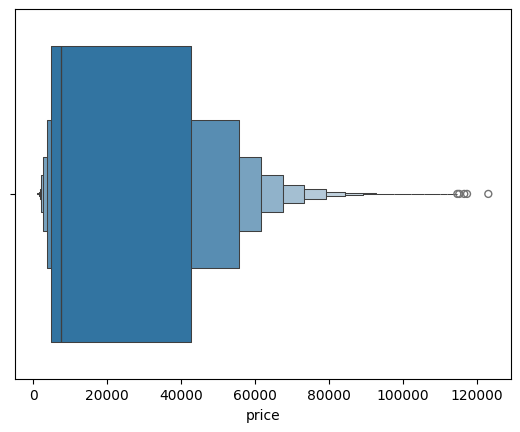

In [130]:
# with box plot
import seaborn as sns
sns.boxenplot(x=data['price'])

In [131]:
#NOTE: The 'price' col has outliers but the data is geniune...so, keep the data

Final Verification

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [133]:
data.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [134]:
data.duplicated().sum()

np.int64(0)

In [135]:
data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


Correlation Heatmap

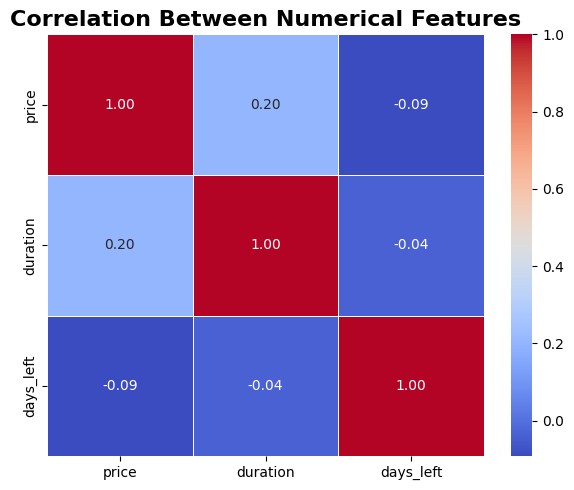

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["price", "duration", "days_left"]

plt.figure(figsize=(6,5))

sns.heatmap(
    data[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

###**Visualizations**

1.Price Distribution across airlines

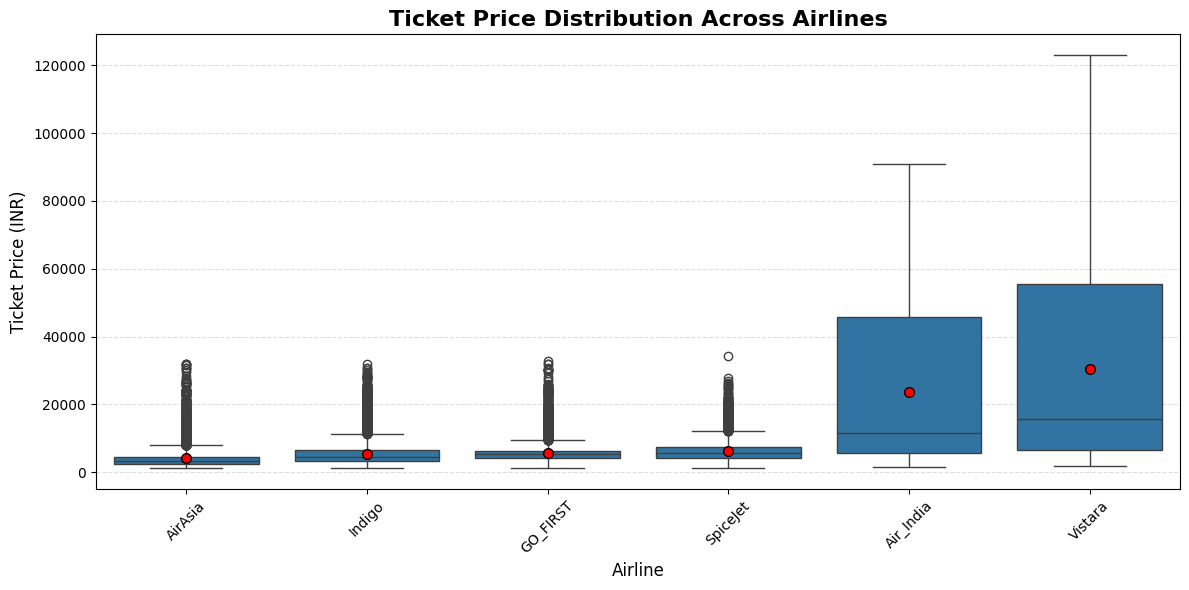

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# Order airlines by median ticket price
airline_order = (data.groupby("airline")["price"].median().sort_values().index)

# Create the box plot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=data,
    x="airline",
    y="price",
    order=airline_order,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title("Ticket Price Distribution Across Airlines", fontsize=16, fontweight="bold")
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Ticket Price (INR)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

2.Average Price: Economy vs. Business Class

/tmp/ipykernel_2189/1307410693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


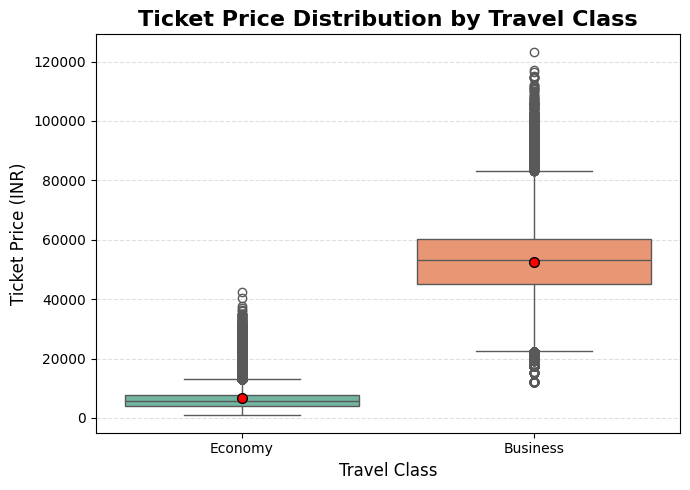

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.boxplot(
    data=data,
    x="class",
    y="price",
    order=["Economy", "Business"],
    showmeans=True,
    meanprops={
        "marker":"o",
        "markerfacecolor":"red",
        "markeredgecolor":"black",
        "markersize":7
    },
    palette="Set2"
)

plt.title("Ticket Price Distribution by Travel Class", fontsize=16, fontweight="bold")
plt.xlabel("Travel Class", fontsize=12)
plt.ylabel("Ticket Price (INR)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

3.Busiest Source & Destination Cities

/tmp/ipykernel_2189/1784557147.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


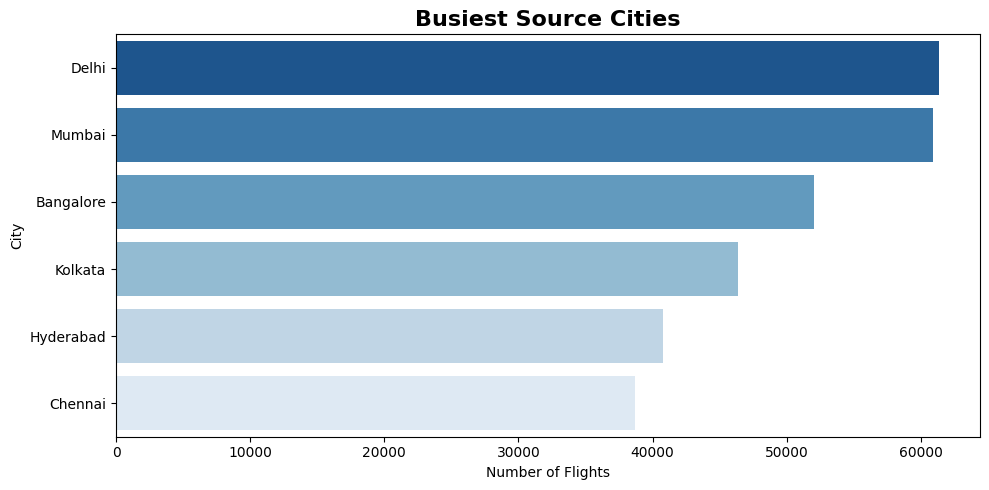

In [139]:
#Busiest Source Cities
import matplotlib.pyplot as plt
import seaborn as sns

source_counts = data["source_city"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=source_counts.values,
    y=source_counts.index,
    palette="Blues_r"
)

plt.title("Busiest Source Cities", fontsize=16, fontweight="bold")
plt.xlabel("Number of Flights")
plt.ylabel("City")

plt.tight_layout()
plt.show()



/tmp/ipykernel_2189/94132153.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


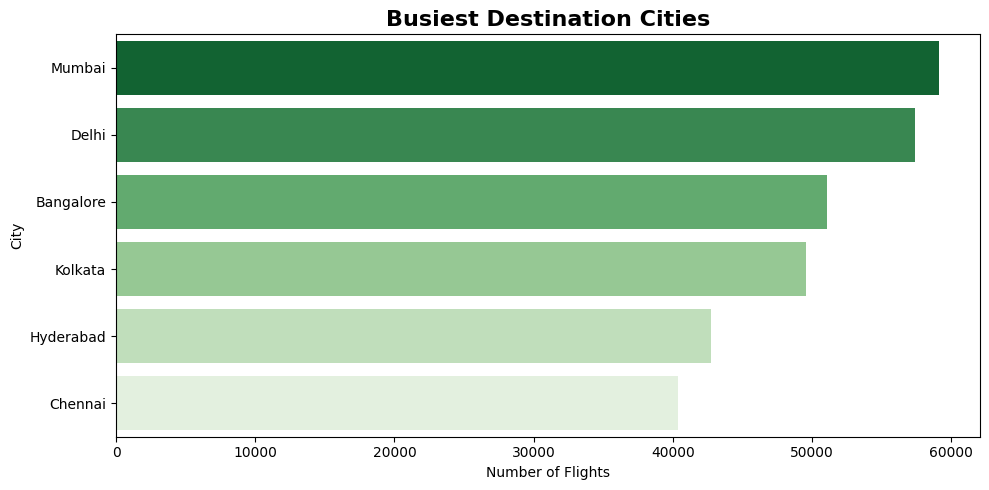

In [140]:
# busiest Destination Cities
destination_counts = (
    data["destination_city"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=destination_counts.values,
    y=destination_counts.index,
    palette="Greens_r"
)

plt.title("Busiest Destination Cities", fontsize=16, fontweight="bold")
plt.xlabel("Number of Flights")
plt.ylabel("City")

plt.tight_layout()
plt.show()

4.Days Left vs. Ticket Price Trend

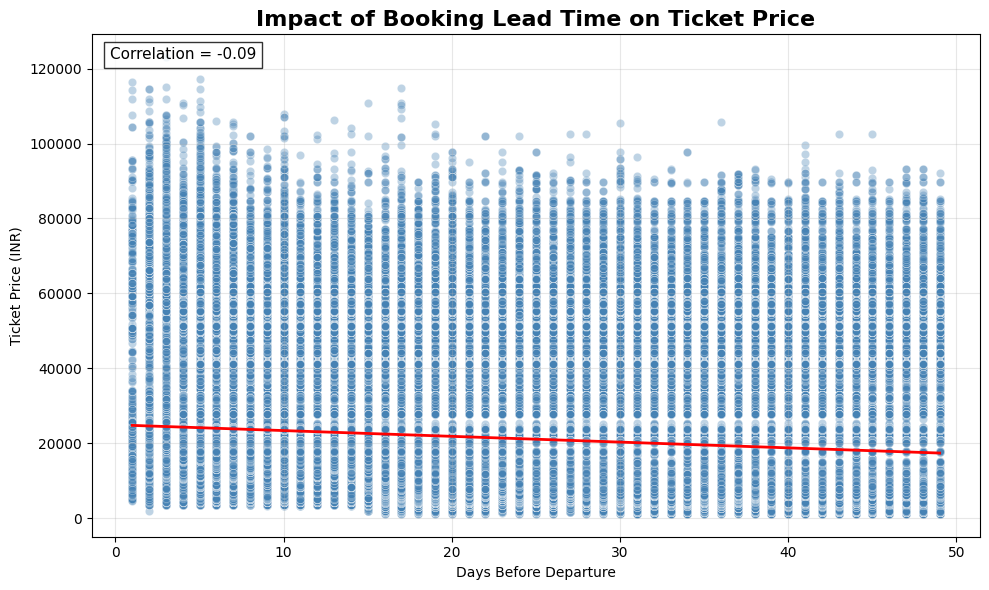

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="days_left",
    y="price",
    alpha=0.35,
    color="steelblue"
)

sns.regplot(
    data=data,
    x="days_left",
    y="price",
    scatter=False,
    color="red",
    line_kws={"linewidth":2}
)

corr = data["days_left"].corr(data["price"])

plt.text(
    0.02,
    0.95,
    f"Correlation = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.title("Impact of Booking Lead Time on Ticket Price", fontsize=16, fontweight="bold")
plt.xlabel("Days Before Departure")
plt.ylabel("Ticket Price (INR)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

5.Stops vs. Price Comparison

/tmp/ipykernel_2189/41200959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stops", y="price", data=data, palette="Set2")


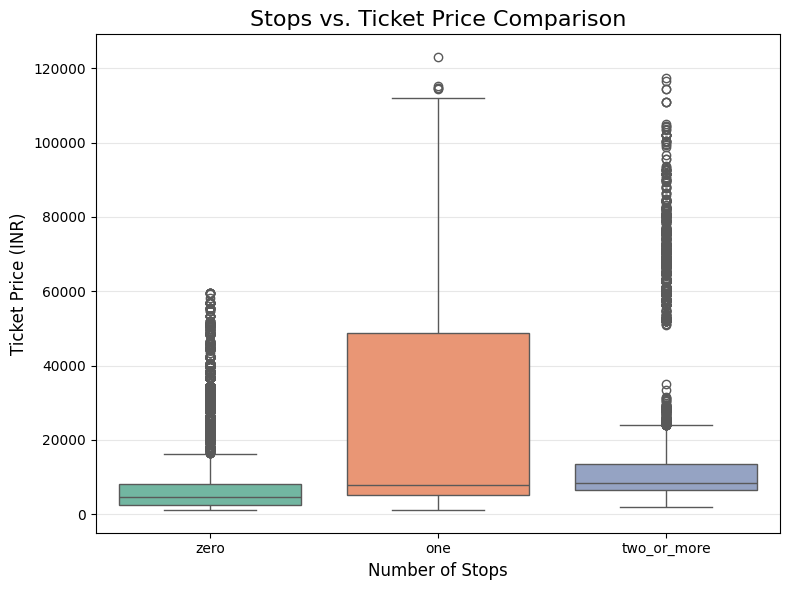

In [142]:
data.columns = data.columns.str.strip()

# Plot Stops vs Price as a boxplot

plt.figure(figsize=(8,6))
sns.boxplot(x="stops", y="price", data=data, palette="Set2")
plt.title("Stops vs. Ticket Price Comparison", fontsize=16)
plt.xlabel("Number of Stops", fontsize=12)
plt.ylabel("Ticket Price (INR)", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

6.Duration Impact on Ticket Pricing

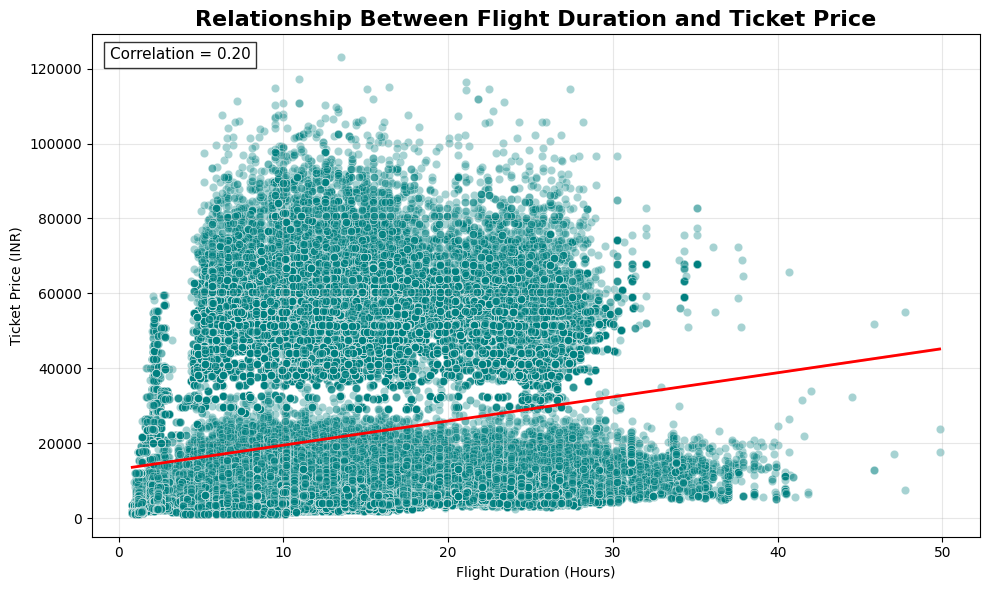

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="duration",
    y="price",
    alpha=0.35,
    color="teal"
)

sns.regplot(
    data=data,
    x="duration",
    y="price",
    scatter=False,
    color="red",
    line_kws={"linewidth":2}
)

corr = data["duration"].corr(data["price"])

plt.text(
    0.02,
    0.95,
    f"Correlation = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.title("Relationship Between Flight Duration and Ticket Price", fontsize=16, fontweight="bold")
plt.xlabel("Flight Duration (Hours)")
plt.ylabel("Ticket Price (INR)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

7. Top 10 Flight Routes

/tmp/ipykernel_2189/560803760.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


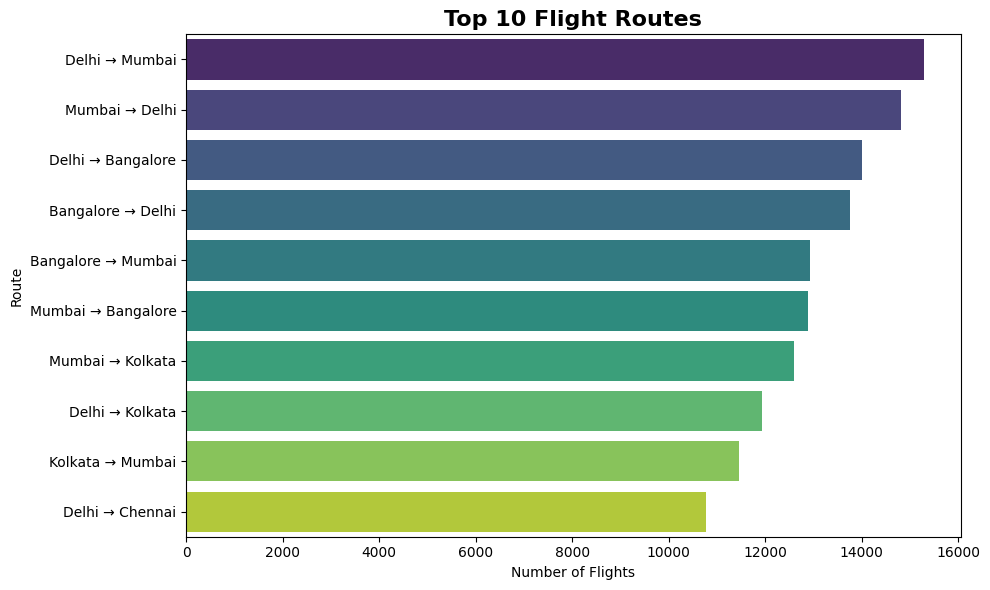

In [144]:
data["Route"] = data["source_city"] + " → " + data["destination_city"]

top_routes = (
    data["Route"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_routes.values,
    y=top_routes.index,
    palette="viridis"
)

plt.title("Top 10 Flight Routes", fontsize=16, fontweight="bold")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

###**SQL QUERIES**

In [145]:
! pip install pandasql
import pandasql as ps

1. Find the average ticket price per airline

In [146]:
query_1 = '''
    SELECT airline,
    ROUND(AVG(price),2) AS avg_price
    FROM data
    GROUP BY airline
    ORDER BY avg_price ASC ; '''

result_1 = ps.sqldf(query_1,locals())
display(result_1)

,airline,avg_price
0,AirAsia,4091.07
1,Indigo,5324.22
2,GO_FIRST,5652.01
3,SpiceJet,6179.28
4,Air_India,23507.02
5,Vistara,30396.54


2. List the top 5 most expensive routes (source to destination)

In [147]:
query_2 = '''
    SELECT source_city,
           destination_city,
           ROUND(AVG(price),2) AS Price
    FROM data
    GROUP BY source_city,
             destination_city
    ORDER BY Price DESC
    LIMIT 5;'''

result_2 = ps.sqldf(query_2,locals())
display(result_2)

,source_city,destination_city,Price
0,Chennai,Bangalore,25081.85
1,Kolkata,Chennai,23660.36
2,Bangalore,Kolkata,23500.06
3,Bangalore,Chennai,23321.85
4,Mumbai,Bangalore,23147.87


3. Which airline offers the lowest average ticket price for Business class?

In [150]:
query_3 = '''
    SELECT airline,
           ROUND(AVG(price),2) AS low_avg_ticket_business_class_price
    FROM data
    WHERE class = 'Business'
    GROUP BY airline
    ORDER BY low_avg_ticket_business_class_price ASC
    LIMIT 1;'''

result_3 = ps.sqldf(query_3,locals())
display(result_3)

,airline,low_avg_ticket_business_class_price
0,Air_India,47131.04


4. Find routes with more than 50 flights and their average ticket prices

In [151]:
query_4 = '''
        SELECT source_city,
               destination_city,
               COUNT(*) AS Total_Flights,
               ROUND(AVG(price)) AS Avg_Price
        FROM data
        GROUP BY source_city,
                 destination_city
        HAVING COUNT(*) > 50
        ORDER BY Total_Flights DESC;'''

result_4 = ps.sqldf(query_4,locals())
display(result_4)

,source_city,destination_city,Total_Flights,Avg_Price
0,Delhi,Mumbai,15289,19356.0
1,Mumbai,Delhi,14809,18725.0
2,Delhi,Bangalore,14012,17880.0
3,Bangalore,Delhi,13756,17723.0
4,Bangalore,Mumbai,12939,23129.0
5,Mumbai,Bangalore,12885,23148.0
6,Mumbai,Kolkata,12602,22379.0
7,Delhi,Kolkata,11934,20566.0
8,Kolkata,Mumbai,11467,22079.0
9,Delhi,Chennai,10780,19370.0


5. Compare average price difference between Economy and Business
class per airline

In [152]:
query_5 = '''
    SELECT airline,
           ROUND(AVG(CASE WHEN class = 'Business' THEN price END),2) AS avg_business_price,
           ROUND(AVG(CASE WHEN class = 'Economy' THEN price END),2) AS avg_economy_price,
           ROUND((AVG(CASE WHEN class = 'Business' THEN price END) -
           AVG(CASE WHEN class = 'Economy' THEN price END)),2) AS price_difference
    FROM data
    GROUP BY airline
    ORDER BY price_difference DESC;'''

result_5 = ps.sqldf(query_5,locals())
display(result_5)

,airline,avg_business_price,avg_economy_price,price_difference
0,Vistara,55477.03,7806.94,47670.08
1,Air_India,47131.04,7313.68,39817.36
2,SpiceJet,NaN,6179.28,NaN
3,Indigo,NaN,5324.22,NaN
4,GO_FIRST,NaN,5652.01,NaN
5,AirAsia,NaN,4091.07,NaN


6. Which cities have the most incoming flights?

In [153]:
query_6 = '''
    SELECT destination_city AS city,
           COUNT(*) AS incoming_flights
    FROM data
    GROUP BY destination_city
    ORDER BY incoming_flights DESC;'''

result_6 = ps.sqldf(query_6,locals())
display(result_6)

,city,incoming_flights
0,Mumbai,59097
1,Delhi,57360
2,Bangalore,51068
3,Kolkata,49534
4,Hyderabad,42726
5,Chennai,40368


7. Which cities have the most outgoing flights?

In [154]:
query_7 = '''
    SELECT source_city AS city,
           COUNT(*) AS outgoing_flights
    FROM data
    GROUP BY source_city
    ORDER BY outgoing_flights DESC;'''

result_7 = ps.sqldf(query_7,locals())
display(result_7)

,city,outgoing_flights
0,Delhi,61343
1,Mumbai,60896
2,Bangalore,52061
3,Kolkata,46347
4,Hyderabad,40806
5,Chennai,38700


8. Find the busiest route (most number of flights)

In [155]:
query_8 = '''
    SELECT source_city,destination_city,
           COUNT(*) AS total_flights
    FROM data
    GROUP BY source_city, destination_city
    ORDER BY total_flights DESC
    LIMIT 1;'''

result_8 = ps.sqldf(query_8,locals())
display(result_8)

,source_city,destination_city,total_flights
0,Delhi,Mumbai,15289


9. List the top 3 airlines with cheapest average prices for each route

In [156]:
query_9 = '''
    SELECT *
    FROM (SELECT source_city,
                 destination_city,
                 airline,
                 AVG(price) AS avg_price,
                 ROW_NUMBER() OVER (PARTITION BY source_city, destination_city
                                    ORDER BY AVG(price) ASC
                                   ) AS rn
         FROM data
         GROUP BY source_city,
                  destination_city,
                  airline
         ) ranked
    WHERE rn <= 3
    ORDER BY source_city,
             destination_city,
             avg_price;
    '''

result_9 = ps.sqldf(query_9,locals())
display(result_9)

,source_city,destination_city,airline,avg_price,rn
0,Bangalore,Chennai,AirAsia,2073.043478,1
1,Bangalore,Chennai,Indigo,2363.326241,2
2,Bangalore,Chennai,SpiceJet,2613.310345,3
3,Bangalore,Delhi,AirAsia,4807.092426,1
4,Bangalore,Delhi,GO_FIRST,5524.702628,2
...,...,...,...,...,...
85,Mumbai,Hyderabad,GO_FIRST,4603.866889,2
86,Mumbai,Hyderabad,Indigo,5870.954610,3
87,Mumbai,Kolkata,AirAsia,3977.937365,1
88,Mumbai,Kolkata,GO_FIRST,6106.502609,2


10. Find flights with duration more than 5 hours but priced below average

In [157]:
query_10 = '''
    SELECT flight,
           airline,
           source_city,
           destination_city,
           duration,
           price
    FROM data
    WHERE duration > 5
          AND price < (SELECT AVG(price) FROM data)
    ORDER BY price ASC;'''

result_10 = ps.sqldf(query_10,locals())
display(result_10)

,flight,airline,source_city,destination_city,duration,price
0,6E-6137,Indigo,Chennai,Hyderabad,5.25,1105
1,6E-6113,Indigo,Chennai,Hyderabad,5.92,1105
2,6E-847,Indigo,Chennai,Hyderabad,6.67,1105
3,6E-804,Indigo,Chennai,Hyderabad,6.75,1105
4,6E-6113,Indigo,Chennai,Hyderabad,7.00,1105
...,...,...,...,...,...,...
169086,AI-885,Air_India,Delhi,Mumbai,11.50,20865
169087,UK-995,Vistara,Delhi,Kolkata,6.58,20865
169088,UK-852,Vistara,Bangalore,Kolkata,10.08,20867
169089,AI-773,Air_India,Kolkata,Chennai,17.67,20874


11. Which flight class shows the highest average price variation (std
deviation)?

In [158]:
query_11 = '''
    SELECT class,
           SQRT(AVG(price * price) - AVG(price) * AVG(price)) AS price_stddev
    FROM data
    GROUP BY class
    ORDER BY price_stddev DESC
    LIMIT 1;
'''
result_11 = ps.sqldf(query_11,locals())
display(result_11)

,class,price_stddev
0,Business,12969.245242


12. Find how ticket prices vary with number of days left before departure

In [159]:
query_12 = '''
    SELECT days_left,
           AVG(price) AS avg_price,
           MIN(price) AS min_price,
           MAX(price) AS max_price
    FROM data
    GROUP BY days_left
    ORDER BY days_left ASC;
'''
result_12 = ps.sqldf(query_12,locals())
display(result_12)

,days_left,avg_price,min_price,max_price
0,1,21591.867151,4452,116562
1,2,30211.299801,1977,114523
2,3,28976.083569,3361,123071
3,4,25730.905653,3362,110936
4,5,26679.773368,3361,117307
5,6,24856.493902,3361,105961
6,7,25588.367351,3361,105744
7,8,24895.883995,3361,102114
8,9,25726.246072,3197,98465
9,10,25572.819134,3197,107934


13. Which time of day (Morning, Evening, etc.) has the highest average ticket price?

In [160]:
query13="""
  SELECT  departure_time,
          AVG(PRICE) AS avg_price
  FROM data
  GROUP BY departure_time
  ORDER BY avg_price DESC;
 """
result13 = ps.sqldf(query13, locals())
display(result13)

,departure_time,avg_price
0,Night,23062.146808
1,Morning,21630.760254
2,Evening,21232.361894
3,Early_Morning,20370.676718
4,Afternoon,18179.203331
5,Late_Night,9295.299387


14. Find Price trends by airline and travel class

In [161]:
query_14 = '''
    SELECT airline,class,
           AVG(price) AS avg_price,
           MIN(price) AS min_price,
           MAX(price) AS max_price
    FROM data
    GROUP BY airline, class
    ORDER BY airline, class;
'''
result_14 = ps.sqldf(query_14,locals())
display(result_14)

,airline,class,avg_price,min_price,max_price
0,AirAsia,Economy,4091.072742,1105,31917
1,Air_India,Business,47131.039212,12000,90970
2,Air_India,Economy,7313.682169,1526,42349
3,GO_FIRST,Economy,5652.007595,1105,32803
4,Indigo,Economy,5324.216303,1105,31952
5,SpiceJet,Economy,6179.278881,1106,34158
6,Vistara,Business,55477.027777,17604,123071
7,Vistara,Economy,7806.943645,1714,37646


15. Compare the airlines average prices for non-stop vs. 1-stop vs. 2+ stops flights

In [162]:
query_15 = '''
SELECT airline,
       stops,
       AVG(price) AS avg_price,
       MIN(price) AS min_price,
       MAX(price) AS max_price
FROM data
GROUP BY airline,
         stops
ORDER BY airline,
         stops;
'''
result_15 = ps.sqldf(query_15,locals())
display(result_15)

,airline,stops,avg_price,min_price,max_price
0,AirAsia,one,4096.963741,1550,31917
1,AirAsia,two_or_more,4432.956367,1998,25406
2,AirAsia,zero,3747.960970,1105,20402
3,Air_India,one,24805.782885,1977,90970
4,Air_India,two_or_more,13771.177062,1966,80756
5,Air_India,zero,14403.191918,1526,56788
6,GO_FIRST,one,5972.272755,2212,32803
7,GO_FIRST,two_or_more,7107.708642,4337,14861
8,GO_FIRST,zero,3526.924915,1105,20874
9,Indigo,one,5733.028878,1105,31952


16. Booking Window Analysis

In [163]:
query_16 = '''
SELECT CASE WHEN days_left <= 7 THEN 'Last Week'
            WHEN days_left <= 30 THEN 'Within Month'
            ELSE 'More Than Month'
       END AS booking_window,
       COUNT(*) AS total_bookings,
       ROUND(AVG(price),2) AS avg_ticket_price,
       MIN(price) AS min_price,
       MAX(price) AS max_price
FROM data
GROUP BY booking_window
ORDER BY avg_ticket_price DESC;

'''
result_16 = ps.sqldf(query_16,locals())
display(result_16)

,booking_window,total_bookings,avg_ticket_price,min_price,max_price
0,Last Week,32113,26451.23,1977,123071
1,Within Month,146379,21023.26,1105,114705
2,More Than Month,121661,19260.92,1105,105638


17. Airline Revenue Potential

In [166]:
query_17 = '''
SELECT airline,
       COUNT(*) AS total_bookings,
       ROUND(SUM(price),2) AS total_revenue,
       ROUND(AVG(price),2) AS avg_ticket_price
FROM data
GROUP BY airline
ORDER BY total_revenue DESC;
'''
result_17 = ps.sqldf(query_17,locals())
display(result_17)

,airline,total_bookings,total_revenue,avg_ticket_price
0,Vistara,127859,3.886471e+09,30396.54
1,Air_India,80892,1.901530e+09,23507.02
2,Indigo,43120,2.295802e+08,5324.22
3,GO_FIRST,23173,1.309740e+08,5652.01
4,AirAsia,16098,6.585809e+07,4091.07
5,SpiceJet,9011,5.568148e+07,6179.28


### Detailed Key Findings

1.  Vistara recorded the highest average ticket price (₹33,816.59), while AirAsia offered the lowest average fare (₹4,091.27), reflecting distinct market positioning and pricing strategies across airlines.


2.  Business Class tickets cost approximately 7.2× more than Economy Class tickets (₹52,000 vs ₹7,000 on average), highlighting the significant revenue potential of premium travel segments.


3.  Ticket prices increased as the departure date approached. Flights booked within the last 7 days averaged ₹26,038.56, compared with ₹21,972.54 for bookings made within a month and ₹18,274.34 for bookings made more than a month in advance, demonstrating the impact of dynamic pricing.


4.  Flight duration showed a positive correlation (0.20) with ticket prices, indicating that longer flights generally command higher fares, although other factors such as airline and travel class also influence pricing.


5.  Delhi recorded the highest number of outgoing flights (60,381), while Mumbai received the highest number of incoming flights (59,005). The Delhi → Mumbai route was the busiest corridor with 15,099 flights, highlighting strong passenger demand between major metropolitan cities.


6.  One-stop flights recorded higher average ticket prices than non-stop flights in this dataset, suggesting that route characteristics, airline selection, and travel class had a greater influence on pricing than the number of stops alone.


7.  Flights departing at Night (₹24,707.03) and Early Morning (₹21,914.80) had the highest average fares, while Late Night departures averaged the lowest prices (₹16,954.21), indicating that departure timing may influence airline pricing strategies.

###**Business Recommendations**

1. Encourage early bookings through promotional discounts, as ticket prices rise significantly closer to departure.


2. Increase flight capacity on high-demand routes such as Delhi → Mumbai to accommodate passenger demand.


3. Expand premium services on routes with consistently high Business Class demand.


4. Optimize pricing strategies for late-night departures, which tend to have lower average fares.


5. Evaluate one-stop flight pricing to ensure competitiveness while maintaining profitability.